# Φάση Ε: Model Evaluation & Σύγκριση

**Υπεύθυνος:** ML Engineer

**Μετρικές:**
- Accuracy
- Precision / Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

**Οπτικοποιήσεις:**
1. Confusion Matrix (heatmap)
2. ROC Curve
3. Συγκριτικά bar charts
4. Πίνακας σύγκρισης

Φόρτωση προβλέψεων...

1. CLASSIFICATION REPORTS

--- Random Forest ---
              precision    recall  f1-score   support

   No Stroke       0.99      0.64      0.78       945
      Stroke       0.10      0.88      0.18        42

    accuracy                           0.65       987
   macro avg       0.55      0.76      0.48       987
weighted avg       0.95      0.65      0.75       987


--- Support Vector Machine ---
              precision    recall  f1-score   support

   No Stroke       0.99      0.72      0.83       945
      Stroke       0.11      0.79      0.20        42

    accuracy                           0.72       987
   macro avg       0.55      0.75      0.51       987
weighted avg       0.95      0.72      0.81       987



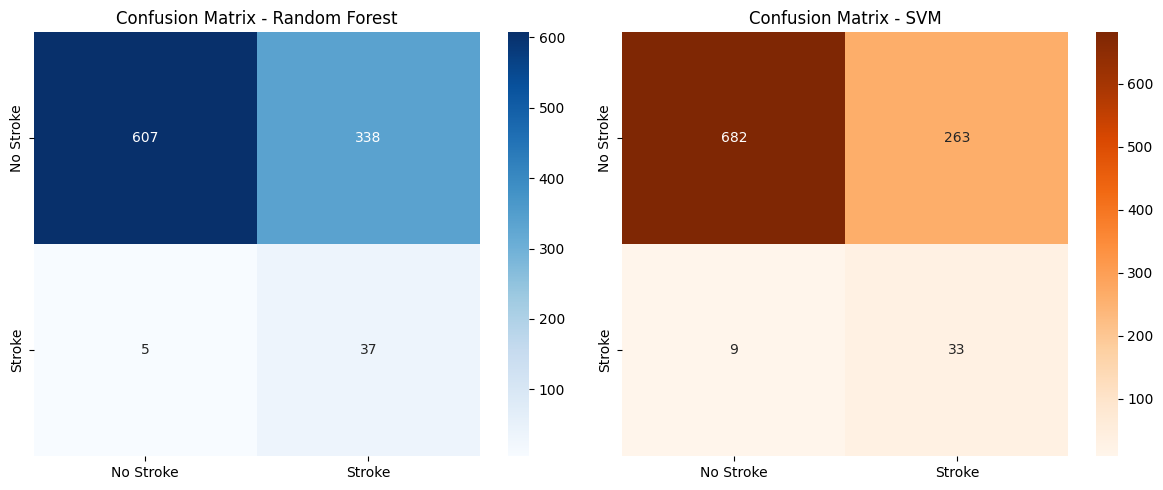

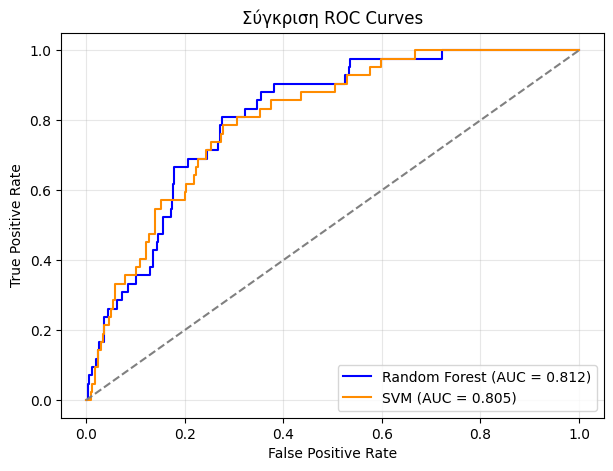


2. K-MEANS CLUSTERING (ADVANCED TECHNIQUE)


/tmp/ipykernel_1894631/2351498452.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stroke_rates.index, y=stroke_rates.values, palette='Set1', ax=axes[1])


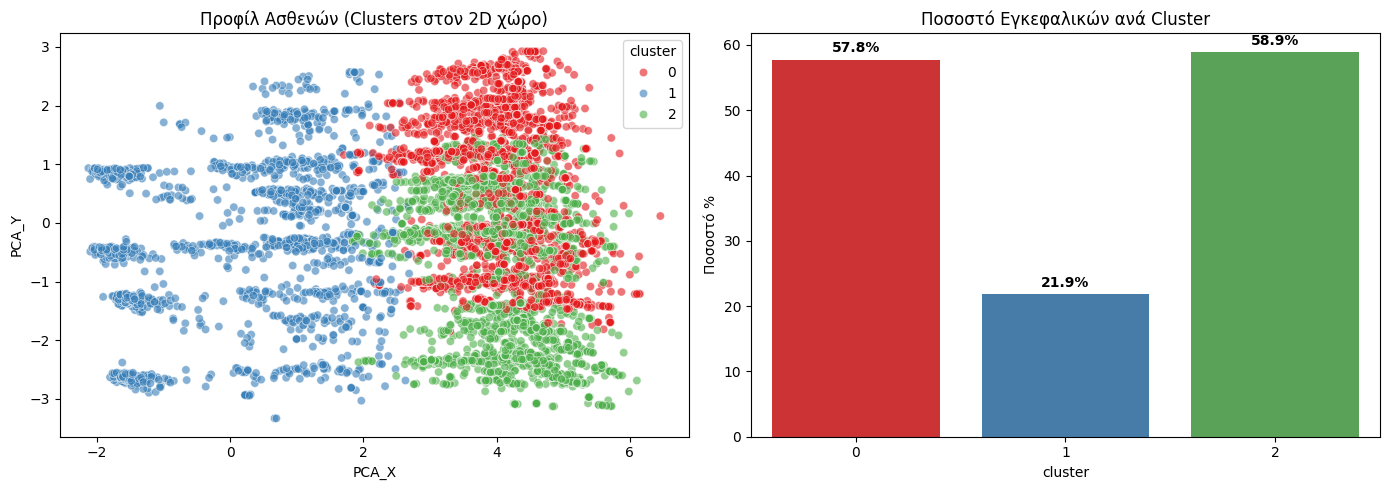

In [ ]:
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc, 
                             accuracy_score, precision_score, recall_score, silhouette_score)

# 1. Εκκίνηση Spark (μόνο για να διαβάσουμε τα Parquet)
print("Εκκίνηση SparkSession...")
spark = SparkSession.builder.appName("Evaluation_Metrics").master("local[*]").getOrCreate()

# 2. Φόρτωση προβλέψεων με τα δικά σου ονόματα αρχείων
print("Φόρτωση προβλέψεων...")
df_rf = spark.read.parquet("../data/rf_predictions.parquet").toPandas()
df_svm = spark.read.parquet("../data/svm_predictions.parquet").toPandas()
df_kmeans = spark.read.parquet("../data/preds_kmeans.parquet").toPandas()

# =========================================================
# ΜΕΡΟΣ Α: ΑΞΙΟΛΟΓΗΣΗ CLASSIFICATION (Βάσει Εκφώνησης)
# Μοντέλα: Random Forest & SVM
# Metrics: Accuracy, Precision, Recall, Confusion Matrix, ROC Curve
# =========================================================
print("\n" + "="*60)
print("1. CLASSIFICATION EVALUATION (RF & SVM)")
print("="*60)

# --- Random Forest Metrics ---
rf_acc = accuracy_score(df_rf['stroke'], df_rf['prediction'])
rf_prec = precision_score(df_rf['stroke'], df_rf['prediction'])
rf_rec = recall_score(df_rf['stroke'], df_rf['prediction'])

print("\n--- Αποτελέσματα Random Forest ---")
print(f"Accuracy:  {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall:    {rf_rec:.4f}")
print("\nClassification Report (RF):")
print(classification_report(df_rf['stroke'], df_rf['prediction'], target_names=['No Stroke', 'Stroke']))

# --- SVM Metrics ---
svm_acc = accuracy_score(df_svm['stroke'], df_svm['prediction'])
svm_prec = precision_score(df_svm['stroke'], df_svm['prediction'])
svm_rec = recall_score(df_svm['stroke'], df_svm['prediction'])

print("\n--- Αποτελέσματα Support Vector Machine ---")
print(f"Accuracy:  {svm_acc:.4f}")
print(f"Precision: {svm_prec:.4f}")
print(f"Recall:    {svm_rec:.4f}")
print("\nClassification Report (SVM):")
print(classification_report(df_svm['stroke'], df_svm['prediction'], target_names=['No Stroke', 'Stroke']))

# --- Γραφήματα 1: Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(df_rf['stroke'], df_rf['prediction']), annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[0].set_title('Confusion Matrix - Random Forest', fontweight='bold')
axes[0].set_xlabel('Προβλεπόμενη Τιμή')
axes[0].set_ylabel('Πραγματική Τιμή')

sns.heatmap(confusion_matrix(df_svm['stroke'], df_svm['prediction']), annot=True, fmt='d', cmap='Oranges', ax=axes[1], xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[1].set_title('Confusion Matrix - SVM', fontweight='bold')
axes[1].set_xlabel('Προβλεπόμενη Τιμή')
axes[1].set_ylabel('Πραγματική Τιμή')

plt.tight_layout()
plt.show()

# --- Γραφήματα 2: ROC Curves ---
fpr_rf, tpr_rf, _ = roc_curve(df_rf['stroke'], df_rf['probability'].apply(lambda x: x[1]))
fpr_svm, tpr_svm, _ = roc_curve(df_svm['stroke'], df_svm['rawPrediction'].apply(lambda x: x[1]))

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})')
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label=f'SVM (AUC = {auc(fpr_svm, tpr_svm):.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.title('Σύγκριση Καμπυλών ROC', fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


# =========================================================
# ΜΕΡΟΣ Β: ΑΞΙΟΛΟΓΗΣΗ K-MEANS (Clustering Evaluation)
# Metrics: Silhouette Score, Cluster Purity
# =========================================================
print("\n" + "="*60)
print("2. K-MEANS EVALUATION (ADVANCED TECHNIQUE)")
print("="*60)

# Εξαγωγή συντεταγμένων X, Y από το PCA vector
df_kmeans['PCA_X'] = df_kmeans['pca_features'].apply(lambda x: x[0])
df_kmeans['PCA_Y'] = df_kmeans['pca_features'].apply(lambda x: x[1])

# --- Υπολογισμός Silhouette Score (Το "Accuracy" του Clustering) ---
# Δείχνει πόσο καλά και συμπαγή είναι τα 3 clusters που δημιουργήσαμε
sil_score = silhouette_score(df_kmeans[['PCA_X', 'PCA_Y']], df_kmeans['cluster'])
print(f"Silhouette Score: {sil_score:.4f} (Τιμές κοντά στο 1 δείχνουν τέλειο διαχωρισμό των ομάδων)\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Γράφημα 1: Οπτική αξιολόγηση των Clusters
sns.scatterplot(data=df_kmeans, x='PCA_X', y='PCA_Y', hue='cluster', palette='Set1', alpha=0.6, ax=axes[0])
axes[0].set_title('Οπτική Αξιολόγηση Προφίλ Ασθενών (Clusters)', fontweight='bold')
axes[0].set_xlabel('Κύρια Συνιστώσα 1 (PCA_X)')
axes[0].set_ylabel('Κύρια Συνιστώσα 2 (PCA_Y)')

# Γράφημα 2: Cluster Analysis / Purity (Αντικαθιστά το Confusion Matrix)
stroke_rates = df_kmeans.groupby('cluster')['stroke'].mean() * 100
sns.barplot(x=stroke_rates.index, y=stroke_rates.values, palette='Set1', ax=axes[1])
axes[1].set_title('Αξιολόγηση Κινδύνου (Ποσοστό Εγκεφαλικών ανά Cluster)', fontweight='bold')
axes[1].set_xlabel('Cluster (Προφίλ Ασθενούς)')
axes[1].set_ylabel('Ποσοστό % (Stroke = 1)')
axes[1].set_ylim(0, max(stroke_rates) + 10) # Δυναμικό όριο Y άξονα

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()